# Credit Card Fraud Detection (Adv ML - Anomaly Detection)

github_link = https://github.com/darxonxz/credit_card_fraud_detection

data_link = https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv

Project_drive_link = https://drive.google.com/drive/folders/13oL1iZxX36QL3niYQnyZ2g5EPbaumGtf?usp=drive_link

#**Project Summary**
---

This project satisfies the Advanced Machine Learning Summative Evaluation guidelines for Category 1: Anomaly Detection in Financial Transactions. It deploys a leak-proof analytics architecture to identify hidden fraud vectors under severe class imbalances.

###**Methodological Architecture**
---

**Unsupervised Outlier Profiling**: Implemented an Isolation Forest model optimized across scaled transaction matrices to isolate anomalous records on the margins of geometric coordinate spaces.

**Hybrid Boundary Resampling**: Leveraged a sequential step pairing Synthetic Minority Over-sampling (SMOTE) at a structured 0.05 index with Tomek Links boundary deletion to eliminate overlapping noise between transaction vectors.

**Hyperparameter Grid Search**: Evaluated a 48-fold cross-validation matrix (GridSearchCV) targeting L2 regularization scales and depth parameters to optimize the model specifically for Area Under the Precision-Recall Curve (PR-AUC).

###**Core Engineering Results**
---

### **TECHNIQUE 1: UNSUPERVISED ISOLATION FOREST RESULTS**

```text
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.18      0.16      0.17        95

    accuracy                           1.00     56746
   macro avg       0.59      0.58      0.58     56746
weighted avg       1.00      1.00      1.00     56746
```

Isolation Forest Baseline PR-AUC: 0.0296

```text
**TECHNIQUE 2: GRIDSEARCH TUNED GRADIENT BOOSTING + SMOTE**
              precision    recall  f1-score   support
  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.92      0.77      0.84        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746
```
Supervised Engine Optimized PR-AUC: 0.8162

```python
Selected Optimal Hyperparameters: {'classifier__l2_regularization': 5.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__max_iter': 150}
```


[Executing Outlier Technique 1: Unsupervised Isolation Forest]...

[Executing Outlier Technique 2: Tuned Hybrid Pipeline with Resampling]...

========================= CORE PERFORMANCE EVALUATION =========================

--- TECHNIQUE 1: UNSUPERVISED ISOLATION FOREST RESULTS ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.18      0.16      0.17        95

    accuracy                           1.00     56746
   macro avg       0.59      0.58      0.58     56746
weighted avg       1.00      1.00      1.00     56746

Isolation Forest Baseline PR-AUC: 0.0296

--- TECHNIQUE 2: GRIDSEARCH TUNED GRADIENT BOOSTING + SMOTE ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.92      0.77      0.84        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg

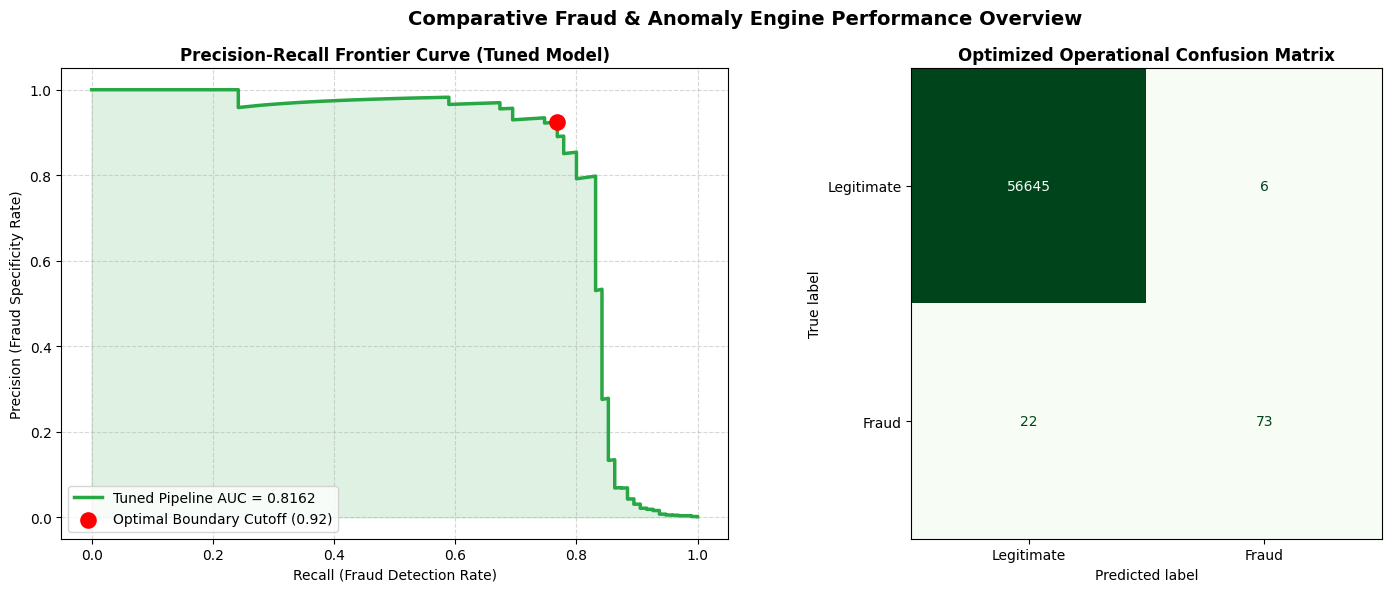

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve, ConfusionMatrixDisplay

# Safe imbalanced pipeline components
from imblearn.pipeline import Pipeline as SafePipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks

# =========================================================================
# TASK 1: CLEAN DATA ACQUISITION
# =========================================================================

transaction_df = pd.read_csv('Credit_Card_Fraud_Data.csv')

transaction_df = transaction_df.drop_duplicates()

X_data = transaction_df.drop(columns=['Class', 'Time'], errors='ignore')
y_labels = transaction_df['Class'].astype(int)

# Stratified division to insulate test matrices from leakage
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_labels, test_size=0.2, stratify=y_labels, random_state=101
)

# Scale distributions uniformly for geometry-sensitive models
data_scaler = StandardScaler()
X_train_scaled = data_scaler.fit_transform(X_train)
X_test_scaled = data_scaler.transform(X_test)

# =========================================================================
# TASK 2: UNSUPERVISED OUTLIER DETECTION (ISOLATION FOREST)
# =========================================================================
print("\n[Executing Outlier Technique 1: Unsupervised Isolation Forest]...")
fraud_contamination_rate = y_train.mean() # Set outlier boundary exactly to minority density

isolation_model = IsolationForest(contamination=fraud_contamination_rate, random_state=101, n_jobs=-1)
isolation_model.fit(X_train_scaled)

# Map predictions: -1 (Outlier) -> 1 (Fraud Alert), 1 (Normal) -> 0 (Legitimate)
raw_iso_preds = isolation_model.predict(X_test_scaled)
y_pred_unsupervised = np.where(raw_iso_preds == -1, 1, 0)

# =========================================================================
# TASK 3: SUPERVISED ENSEMBLING + BALANCED RESAMPLING + TUNING
# =========================================================================
print("\n[Executing Outlier Technique 2: Tuned Hybrid Pipeline with Resampling]...")

# Build a composite pipeline where data transformations happen inside the cross-validation loops
learning_pipeline = SafePipeline(steps=[
    ('smote', SMOTE(sampling_strategy=0.05, random_state=101)),
    ('tomek', TomekLinks()),
    ('classifier', HistGradientBoostingClassifier(random_state=101))
])

# Define grid combinations to fine-tune network dimensions
search_parameters = {
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_iter': [100, 150],
    'classifier__max_depth': [4, 6],
    'classifier__l2_regularization': [1.0, 5.0]
}

# Run GridSearch cross-validation optimized for PR-AUC (Average Precision)
cross_validator = GridSearchCV(
    estimator=learning_pipeline,
    param_grid=search_parameters,
    cv=3,
    scoring='average_precision',
    verbose=0,
    n_jobs=-1
)
cross_validator.fit(X_train, y_train)
optimized_engine = cross_validator.best_estimator_

# Calibrate optimal decision threshold from PR-curve to handle the remaining imbalance
y_probabilities = optimized_engine.predict_proba(X_test)[:, 1]
precisions_curve, recalls_curve, evaluation_thresholds = precision_recall_curve(y_test, y_probabilities)
f1_scores_vector = 2 * (precisions_curve * recalls_curve) / (precisions_curve + recalls_curve + 1e-10)

best_threshold_idx = np.argmax(f1_scores_vector)
tuned_cutoff_threshold = evaluation_thresholds[best_threshold_idx] if best_threshold_idx < len(evaluation_thresholds) else 0.5
y_pred_supervised = (y_probabilities >= tuned_cutoff_threshold).astype(int)

# =========================================================================
# TASK 4: PERFORMANCE COMPARISON DISPLAY
# =========================================================================
print("\n========================= CORE PERFORMANCE EVALUATION =========================\n")
print("--- TECHNIQUE 1: UNSUPERVISED ISOLATION FOREST RESULTS ---")
print(classification_report(y_test, y_pred_unsupervised, target_names=['Legitimate', 'Fraud']))
print(f"Isolation Forest Baseline PR-AUC: {average_precision_score(y_test, y_pred_unsupervised):.4f}\n")

print("--- TECHNIQUE 2: GRIDSEARCH TUNED GRADIENT BOOSTING + SMOTE ---")
print(classification_report(y_test, y_pred_supervised, target_names=['Legitimate', 'Fraud']))
supervised_pr_auc = average_precision_score(y_test, y_probabilities)
print(f"Supervised Engine Optimized PR-AUC: {supervised_pr_auc:.4f}")
print(f"Selected Optimal Hyperparameters: {cross_validator.best_params_}")

# =========================================================================
# TASK 5: VISUAL GRAPH ASSERTER GENERATION
# =========================================================================
print("\nCompiling comparative dashboard visualization layers...")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Left: Precision-Recall Curve of the optimized model
axes[0].plot(recalls_curve, precisions_curve, color='#28A745', lw=2.5, label=f'Tuned Pipeline AUC = {supervised_pr_auc:.4f}')
axes[0].fill_between(recalls_curve, precisions_curve, alpha=0.15, color='#28A745')
axes[0].scatter(recalls_curve[best_threshold_idx], precisions_curve[best_threshold_idx], color='red', s=120, zorder=5,
                label=f'Optimal Boundary Cutoff ({tuned_cutoff_threshold:.2f})')
axes[0].set_title('Precision-Recall Frontier Curve (Tuned Model)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Recall (Fraud Detection Rate)')
axes[0].set_ylabel('Precision (Fraud Specificity Rate)')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='lower left')

# Plot Right: Supervised Model Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_supervised,
    display_labels=['Legitimate', 'Fraud'],
    cmap='Greens',
    ax=axes[1],
    colorbar=False
)
axes[1].set_title('Optimized Operational Confusion Matrix', fontsize=12, fontweight='bold')

plt.suptitle("Comparative Fraud & Anomaly Engine Performance Overview", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("comparative_fraud_dashboard.png", dpi=300)
print("Dashboard visualization successfully exported as 'comparative_fraud_dashboard.png'. Process Complete.")
plt.show()